<a href="https://colab.research.google.com/github/takutonakamura2004-dev/IMISToolExeA/blob/main/Report/IMISToolA2026_Report4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Report 4 (2026/07/27 ver.A)

for Tools for intelligent interaction systems a (0ALE005 / 0AL5707).

---

* Student ID: (E.g. 202099998)...Erase-and-put-yours-here
* Name: (E.g. 筑波 太郎）...Erase-and-put-yours-here
* Colab account: (E.g. tsukuba.taro.xs@alumni.tsukuba.ac.jp)...Erase-and-put-yours-here

---

Report could be written in English or Japanese. / レポートの記述は日本語でも英語でもよい．

---

---
# Report4A: Live capture query with CIFAR-10 or MNIST  

* Show the way to build a classfier of CIFAR10 or MNIST.
* Provide a python program that captures an image from a camera and that shows its recognition result of the image immediately.

Hint: Each shown in tutorials. Find a way to unite them.



In [2]:
import torch
print(torch.__version__)

import torchvision
print(torchvision.__version__)

2.11.0+cpu
0.26.0+cpu


(You can put text cells around here)

In [3]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

# device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", device)

# dataset
train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

# model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)

# loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

# training
epochs = 5

for epoch in range(epochs):
    model.train()

    for X, y in train_loader:

        X, y = X.to(device), y.to(device)

        pred = model(X)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs} finished")

# test
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for X, y in test_loader:

        X, y = X.to(device), y.to(device)

        pred = model(X)

        correct += (pred.argmax(1) == y).sum().item()
        total += y.size(0)

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")

# save model
torch.save(model.state_dict(), "mnist_model.pth")

print("Model saved as mnist_model.pth")

device = cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 43.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.04MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.55MB/s]


Epoch 1/5 finished
Epoch 2/5 finished
Epoch 3/5 finished
Epoch 4/5 finished
Epoch 5/5 finished
Accuracy: 73.92%
Model saved as mnist_model.pth


<IPython.core.display.Javascript object>

予測結果 = 3


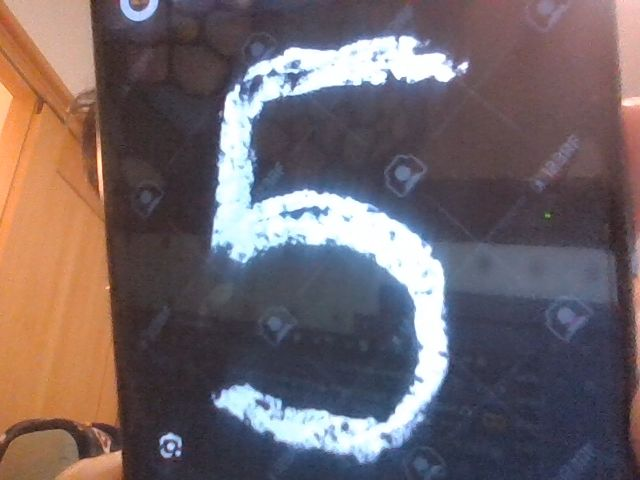

In [13]:
import torch
import torch.nn as nn
from torchvision import transforms

from PIL import Image
from IPython.display import display, Javascript
from google.colab.output import eval_js

from base64 import b64decode
import io

# -------------------------
# モデル定義
# -------------------------
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28,512),
            nn.ReLU(),
            nn.Linear(512,512),
            nn.ReLU(),
            nn.Linear(512,10)
        )

    def forward(self,x):
        x = self.flatten(x)
        return self.linear_relu_stack(x)

# -------------------------
# モデル読み込み
# -------------------------
model = NeuralNetwork()
model.load_state_dict(torch.load("mnist_model.pth", map_location="cpu"))
model.eval()

# -------------------------
# カメラ撮影関数
# -------------------------
def take_photo(filename='photo.jpg', quality=0.8):

    js = Javascript('''
    async function takePhoto(quality) {

      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = '撮影';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';

      const stream =
          await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(
          document.documentElement.scrollHeight,
          true);

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      canvas.getContext('2d').drawImage(
          video, 0, 0);

      stream.getVideoTracks()[0].stop();
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')

    display(js)

    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

# -------------------------
# 撮影
# -------------------------
photo_file = take_photo()

# -------------------------
# 前処理
# -------------------------
img = Image.open(photo_file)

transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((28,28)),
    transforms.ToTensor()
])

x = transform(img).unsqueeze(0)

# -------------------------
# 推論
# -------------------------
with torch.no_grad():
    output = model(x)
    pred = output.argmax(1).item()

print("予測結果 =", pred)

display(img)

---
# Report4B: Tutorials of pytorch

There are [many tutorials](https://github.com/kameda-yoshinari/IMISToolExeA2021/blob/master/300_PyTorch.ipynb) provided by the Pytorch official site. Pick up **two tutorials** (you should complete those tutorials) and make a report for the two tutorials on:

* Summary (2-3 lines)
* What you learn
* The most difficult part

Note that you are encouraged to choose the recommended two .


Tutorial 1: Deep Learning with PyTorch: A 60 Minute Blitz
Summary (2-3 lines)

このチュートリアルでは、PyTorchを用いたディープラーニングの基本的な流れを学習した。テンソルの操作方法、ニューラルネットワークの作成、学習、推論までを実践的に体験できる内容であった。PyTorchによる機械学習開発の全体像を理解することができた。

What I learned
Tensor の基本操作方法
ニューラルネットワークの構築方法
誤差関数と最適化アルゴリズムの利用方法
学習済みモデルによる推論方法
GPUを利用した高速計算の基本
The most difficult part

最も難しかった部分は誤差逆伝播法（Backpropagation）の仕組みの理解であった。PyTorchでは自動微分機能によって簡単に実装できるが、内部でどのように勾配が計算されるかを理解するのに時間がかかった。

Tutorial 2: Learning PyTorch with Examples
Summary (2-3 lines)

このチュートリアルでは、NumPyによる実装から始めて、徐々にPyTorchの機能を活用する形でニューラルネットワークの学習方法を学んだ。自動微分やモジュール化の利点を理解できる構成になっていた。

What I learned
NumPyとPyTorchの違い
Autogradによる自動微分
torch.nnモジュールの利用方法
モデル構築の効率化
コードの再利用性向上の方法
The most difficult part

同じニューラルネットワークを複数の方法で実装していたため、それぞれの実装方法の違いやメリットを理解することが難しかった。特にAutogradを利用した実装と手動で勾配を計算する実装の違いを整理する必要があった。

---
# Report4C: AI support to learn python and PyTorch  

Find out the state-of-the-art AI support which is available / helpful on learning how to write python / pytorch codes on google colab.
Then write your own comment on what kind of changes would happen in a couple of years.

* AI service name
* AI service "official web site"
* Major funcitons of provided support
* The service start date and version history (including the URL that holds such info)


AI service name:

GitHub Copilot

Official website:
https://github.com/features/copilot

Major functions:


*   コード自動生成
*   コード補完

*   エラー解析
*   テストコード生成

*   コード説明
*   ドキュメント生成

*   IDEとの連携によるプログラミング支援


Service start date and version history:


*   2021年6月29日 技術プレビュー公開
*   2022年6月21日 一般提供開始（General Availability）

*   2023年に Copilot X が発表され、チャット機能やドキュメント支援機能が追加された。

My Comment

近年のAI技術の発展によって、PythonやPyTorchの学習方法は大きく変化している。以前はエラーメッセージを検索しながら学習を進める必要があったが、現在ではGitHub CopilotやGeminiのようなAI支援サービスによって、コード生成やデバッグ支援を即座に受けられるようになった。

今後数年以内には、AIは単なるコード生成ツールではなく、学習者一人ひとりの理解度に合わせて説明方法を変更したり、課題を自動生成したりする「AIチューター」として活用されると考えられる。特にGoogle Colabのようなクラウド環境では、AIによる学習支援と実行環境が統合されることで、初心者でも高度なAI開発を効率よく学習できるようになると思う。








(You can put text cells around here)

---
# Report submission

As for Report4, in addition to submit this ipynb, you are also asked to submit 801_miniGPT.ipynb and 802_miniGPT.ipnyb (in total of three files).

You should save this file as a report templete to your local google colaboratory folder and then edit it to fit your report.

The report submission should be made at this cource (0ALE005) at https://manaba.tsukuba.ac.jp .  
Note that 0AL5707 is coupled with 0ALE005 on manaba system, so 0AL5707 students should also submit the report at 0ALE005.  
File extension should be **ipynb**. Other format won't be accepted.  







---
Tools and Practices for Intelligent Interaction Systems A  
Master's and Docotal programs in intelligent and mechanical interaction systems, University of Tsukuba, Japan.  
KAMEDA Yoshinari, SHIBUYA Takeshi  

知能システムツール演習a  
知能機能システム学位プログラム (筑波大学大学院)  
担当：亀田能成，澁谷長史  

2026/07/27. Ver.B. 説明簡略化 / Simplified Explanation  
2026/07/27. Ver.A.  


